## Import the required modules

In [1]:
import matplotlib.pyplot as plt
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any, Dict, Callable
from QMAP_tools.qmap_inspector import QMAPInspector

In [2]:
# Not required but improved the default layout of plots
import scienceplots
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

In [3]:
qm = QMAPInspector()
# Load the helper class which by default has the standard relative paths of the database files so should work out of the box
# in most cases, however if the data is stored else where just use the init kwargs to set the correct path

In [4]:
qm.full_db.filter(pl.col("i") == 1).collect()
# The full database contains all the data needed to make the agg_db and some. It is very important that you do not try load
# the full database into memory so when previewing a standard way is to just filter by pl.col("i") == 1 which restricts the
# database to 1 / 8192 of its full size and therefore can be fully loaded into memory. We are still able to do operations
# on this dataset as you will see later leveraging the LazyFrame.

i,j,face,area,TIR detailed_survey tri_num,TIR detailed_survey band depth 350,TIR detailed_survey band depth 440,TIR detailed_survey slope 1000,TIR detailed_survey ratio 1000,TIR detailed_survey sigma band depth 350,TIR detailed_survey sigma band depth 440,TIR detailed_survey sigma slope 1000,TIR detailed_survey sigma ratio 1000,TIR recona tri_num,TIR recona band depth 350,TIR recona band depth 440,TIR recona slope 1000,TIR recona ratio 1000,TIR recona sigma band depth 350,TIR recona sigma band depth 440,TIR recona sigma slope 1000,TIR recona sigma ratio 1000,TIR reconb tri_num,TIR reconb band depth 350,TIR reconb band depth 440,TIR reconb slope 1000,TIR reconb ratio 1000,TIR reconb sigma band depth 350,TIR reconb sigma band depth 440,TIR reconb sigma slope 1000,TIR reconb sigma ratio 1000,VNIR detailed_survey tri_num,VNIR detailed_survey band depth,VNIR detailed_survey reflectance,VNIR detailed_survey slope1 poly,VNIR detailed_survey slope2 poly,VNIR detailed_survey sigma band depth,…,VNIR recona sigma slope2 poly,VNIR reconc tri_num,VNIR reconc band depth,VNIR reconc reflectance,VNIR reconc slope1 poly,VNIR reconc slope2 poly,VNIR reconc sigma band depth,VNIR reconc sigma reflectance,VNIR reconc sigma slope1 poly,VNIR reconc sigma slope2 poly,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id,Gamma,Tau,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples,TIR detailed_survey tri_num alpha,TIR recona tri_num alpha,TIR reconb tri_num alpha,VNIR detailed_survey tri_num alpha,VNIR recona tri_num alpha,VNIR reconc tri_num alpha
u32,u32,str,f32,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,…,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u8,f32,f32,f32,f32,u8,str,u32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,u32,u32,u32,u32,u32,u32
1,2001,"""negx""",0.001015,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,52,0.009051,0.079066,0.154651,-0.154623,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2002,"""negx""",0.001057,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,63,0.010972,0.079029,0.154657,-0.154623,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2003,"""negx""",0.001048,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,74,0.012779,0.07899,0.154662,-0.154624,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2004,"""negx""",0.000999,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,88,0.015247,0.078953,0.154663,-0.154628,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,1920,"""negx""",0.000975,27132,1.003123,1.01109,1.001736,null,0.001058,0.000682,0.000824,null,432631,null,null,null,null,null,null,null,null,432631,nu

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Define your items
x_item, y_item = "Delta 350", "Delta 440"

custom_lf = qm.full_db.with_columns(
    (pl.col("TIR recona band depth 350") - pl.col("TIR reconb band depth 350")).alias(x_item),
    (pl.col("TIR recona band depth 440") - pl.col("TIR reconb band depth 440")).alias(y_item)
)

X = (
    custom_lf
    .filter(
        pl.col("Delta 350").is_not_nan(),
        pl.col("Delta 440").is_not_nan()
    )
    .select(["Delta 350", "Delta 440"])
    .unique()
    .collect(engine="streaming")
)

# Extract features for clustering
features = (
    X
    .select(["Delta 350", "Delta 440"])
    .to_numpy()
)

# Scale the two dimensions
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# K-means classification
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(features_scaled)

# Add labels back into Polars dataframe
X = X.with_columns(
    pl.Series("population", labels)
)

# Cluster centres back in original units
centres = scaler.inverse_transform(kmeans.cluster_centers_)

print(centres)

[[ 0.00042194  0.00095459]
 [-0.00845803 -0.02651719]]


In [6]:
from sklearn.metrics import silhouette_score

score = silhouette_score(features_scaled, labels)

print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.841


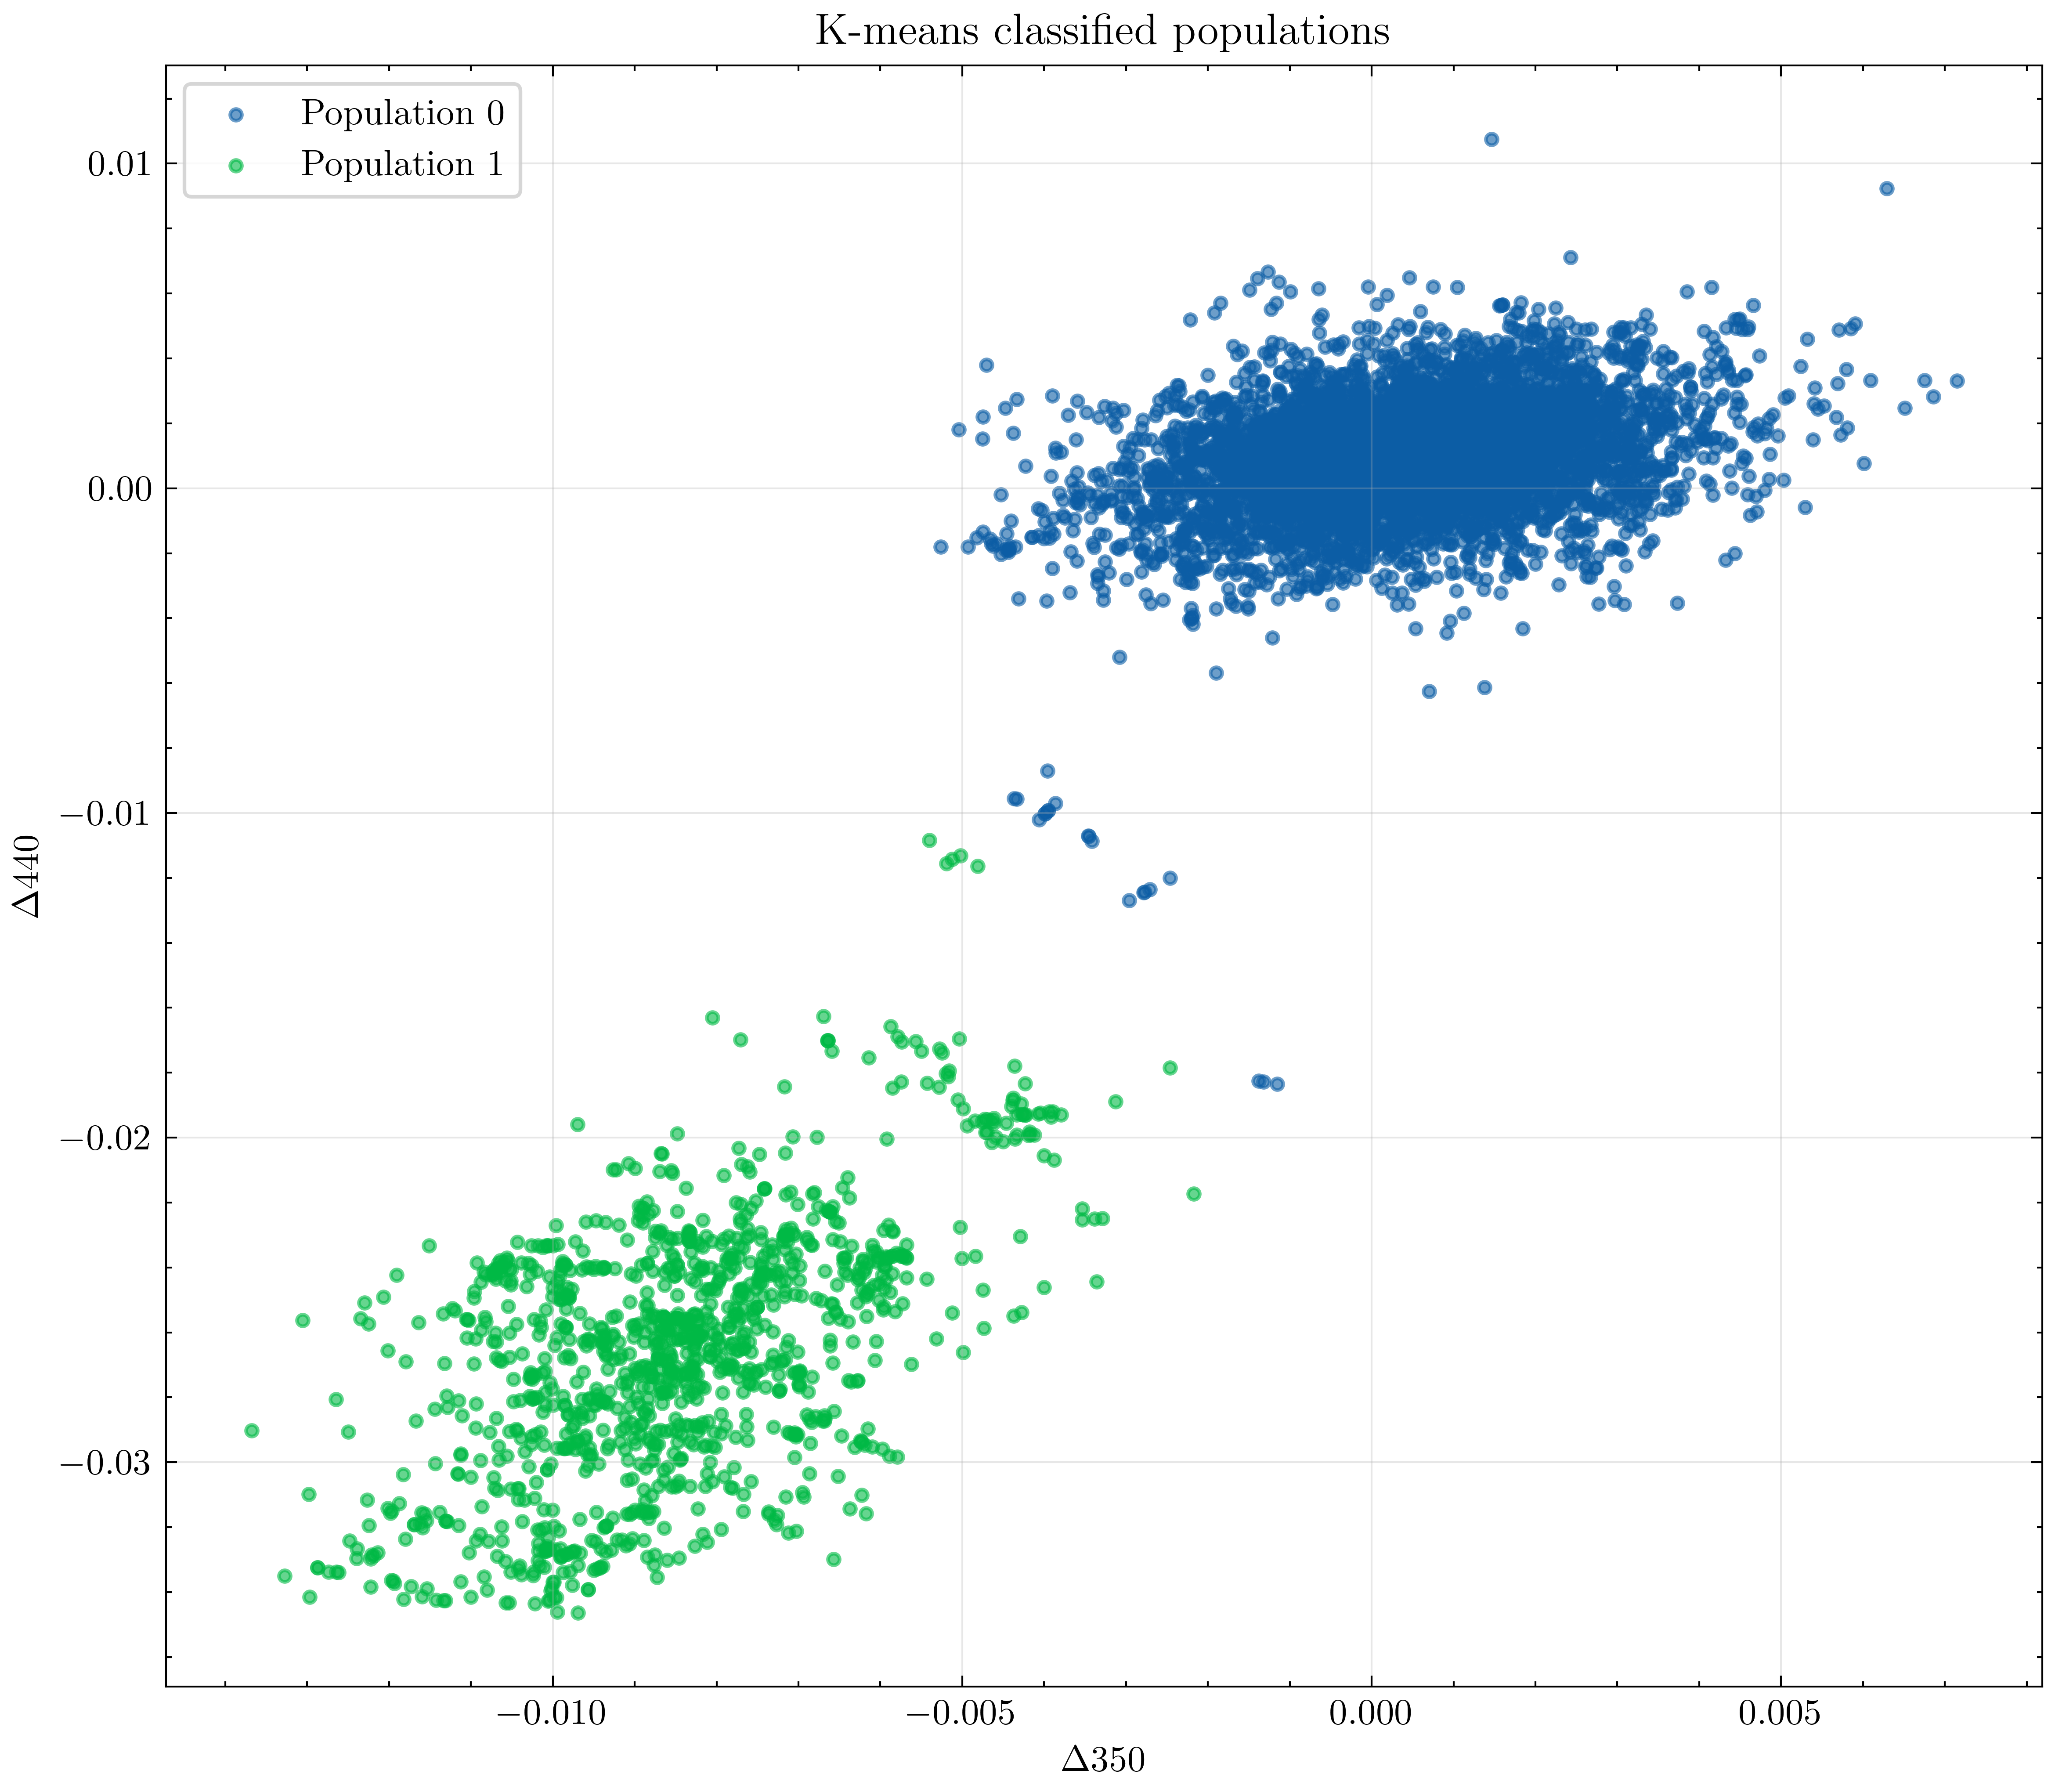

In [7]:
import matplotlib.pyplot as plt

df_plot = X.to_pandas()

plt.figure(figsize=(8, 7))

for pop, group in df_plot.groupby("population"):
    plt.scatter(
        group["Delta 350"],
        group["Delta 440"],
        s=10,
        alpha=0.6,
        label=f"Population {pop}"
    )

plt.xlabel(r"$\Delta 350$")
plt.ylabel(r"$\Delta 440$")
plt.title("K-means classified populations")

plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [8]:
custom_lf_classified = (
    custom_lf
    .join(
        X.select(["Delta 350", "Delta 440", "population"]).lazy(),
        on=["Delta 350", "Delta 440"],
        how="left"
    )
)

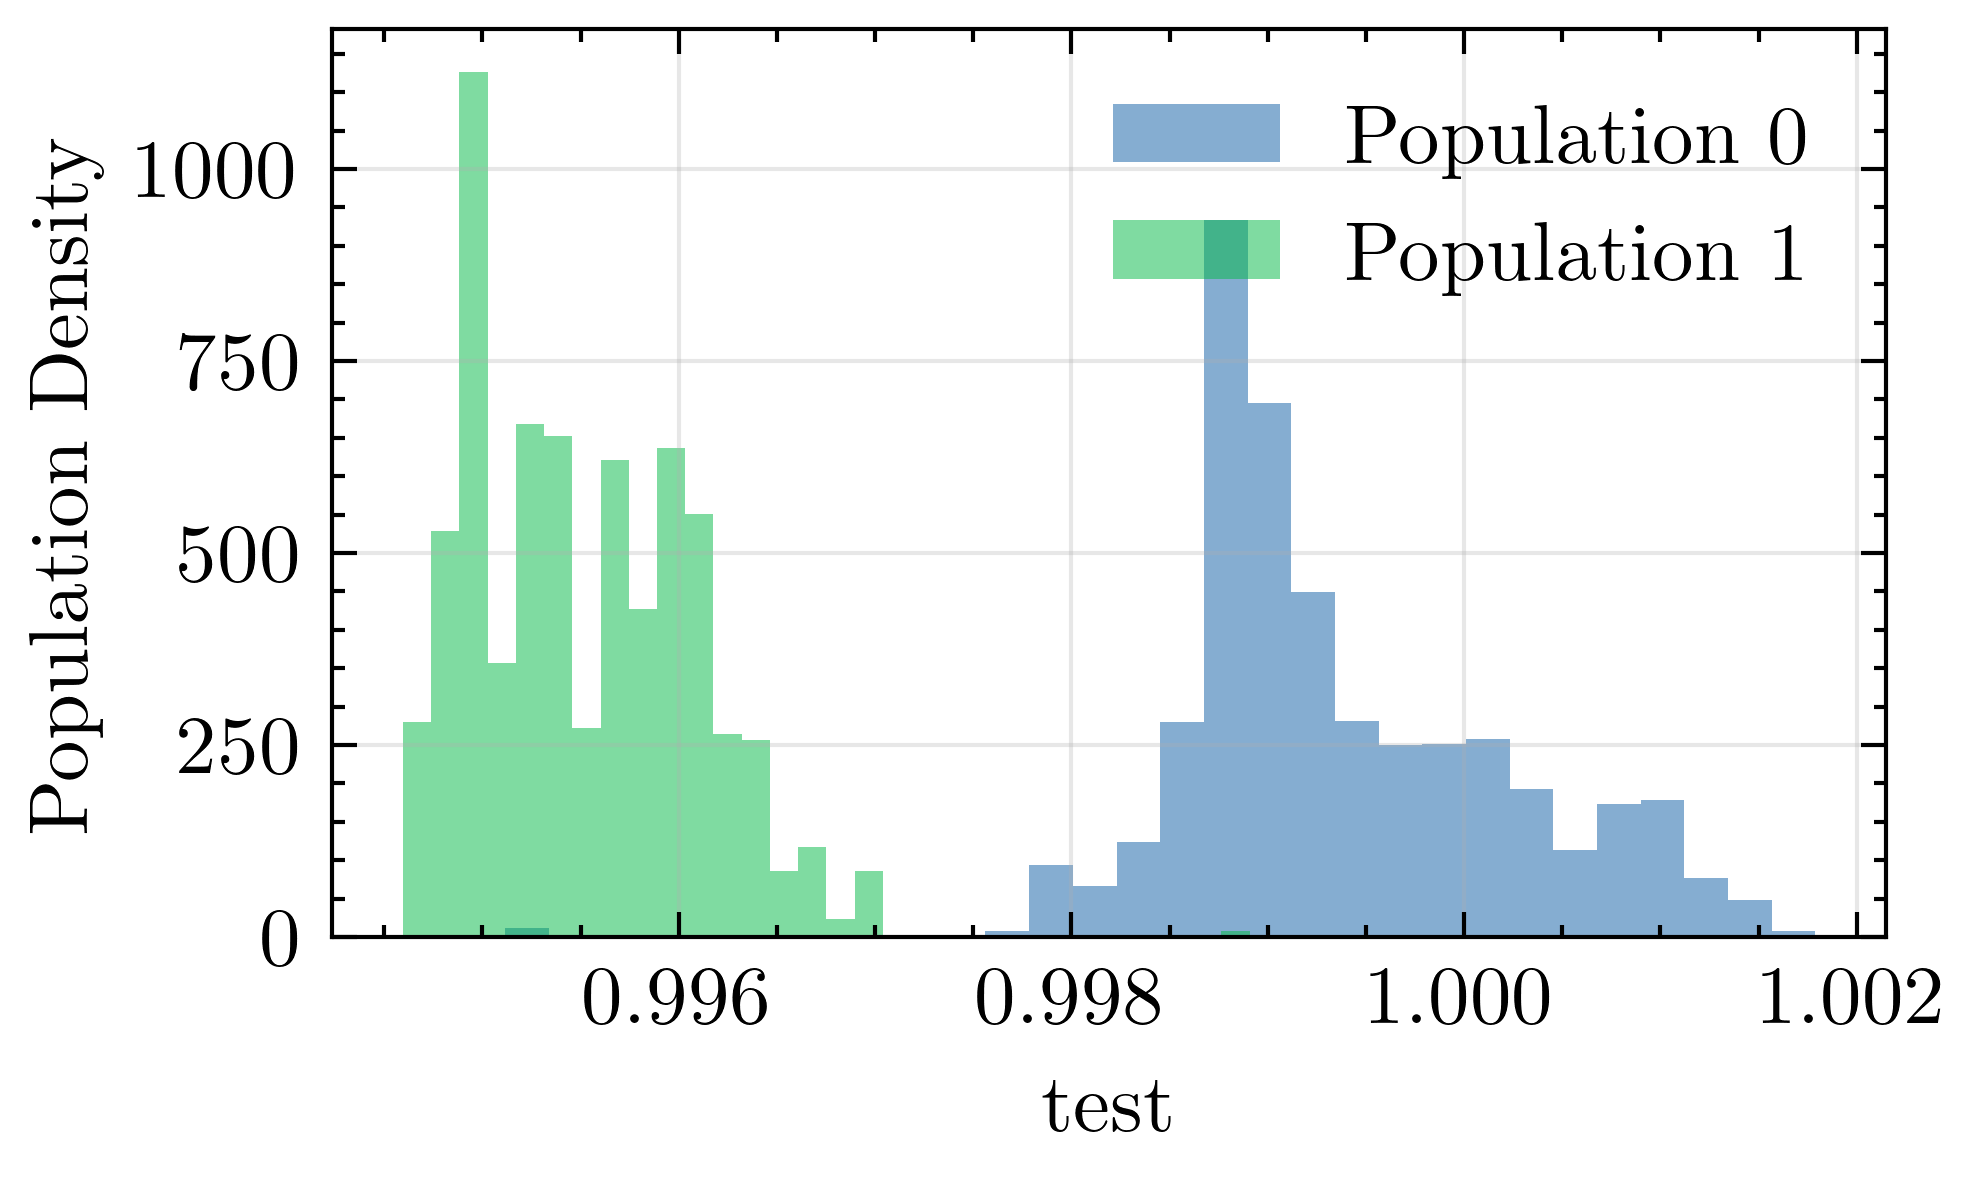

In [9]:
boulder_id_cluster = (
    custom_lf_classified
    .filter(pl.col("population").is_not_null(), pl.col("TIR detailed_survey slope 1000").is_not_nan())
    .group_by("boulder_id")
    .agg(
            pl.col("population").first(),
            pl.col("TIR detailed_survey slope 1000").mean().alias("test")
        )
    .collect(engine="streaming")
)

for pop in boulder_id_cluster["population"].unique().sort():
    gamma = (
        boulder_id_cluster
        .filter(pl.col("population") == pop)
        ["test"]
        .to_numpy()
    )

    plt.hist(
        gamma,
        bins=30,
        alpha=0.5,
        density=True,
        label=f"Population {pop}"
    )

# plt.yscale("log")
plt.xlabel(r"test")
plt.ylabel("Population Density")
# plt.title("Gamma distribution by k-means population")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Define your items
x_item, y_item, z_item = "TIR DS 350", "TIR DS 440", "TIR DS slope 1000"

custom_lf = qm.full_db.with_columns(
    # pl.col("TIR detailed_survey band depth 350").alias(x_item),
    # pl.col("TIR detailed_survey band depth 440").alias(y_item),
    pl.col("TIR detailed_survey slope 1000").alias(z_item)
)

X = (
    custom_lf
    .filter(
        # pl.col(x_item).is_not_nan(),
        # pl.col(y_item).is_not_nan(),
        pl.col(z_item).is_not_nan(),

        pl.col("TIR recona band depth 350").is_not_nan(),
        pl.col("TIR reconb band depth 350").is_not_nan(),
        
    )
    # .group_by(
    #     "boulder_id"
    # )
    # .agg(
    #     pl.col(z_item).mean()
    # )
    .unique()
    .select([z_item]) # , y_item, z_item
    .collect(engine="streaming")
)

# Extract features for clustering
features = (
    X
    .select([z_item]) # , y_item, z_item
    .to_numpy()
)

# Scale the two dimensions
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# K-means classification
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(features_scaled)

# Add labels back into Polars dataframe
X = X.with_columns(
    pl.Series("population", labels)
)

# Cluster centres back in original units
centres = scaler.inverse_transform(kmeans.cluster_centers_)

print(centres)

[[0.99943967]
 [0.99546863]]


In [ ]:
# from sklearn.metrics import silhouette_score

# score = silhouette_score(features_scaled, labels)

# print(f"Silhouette score: {score:.3f}")

KeyboardInterrupt: 

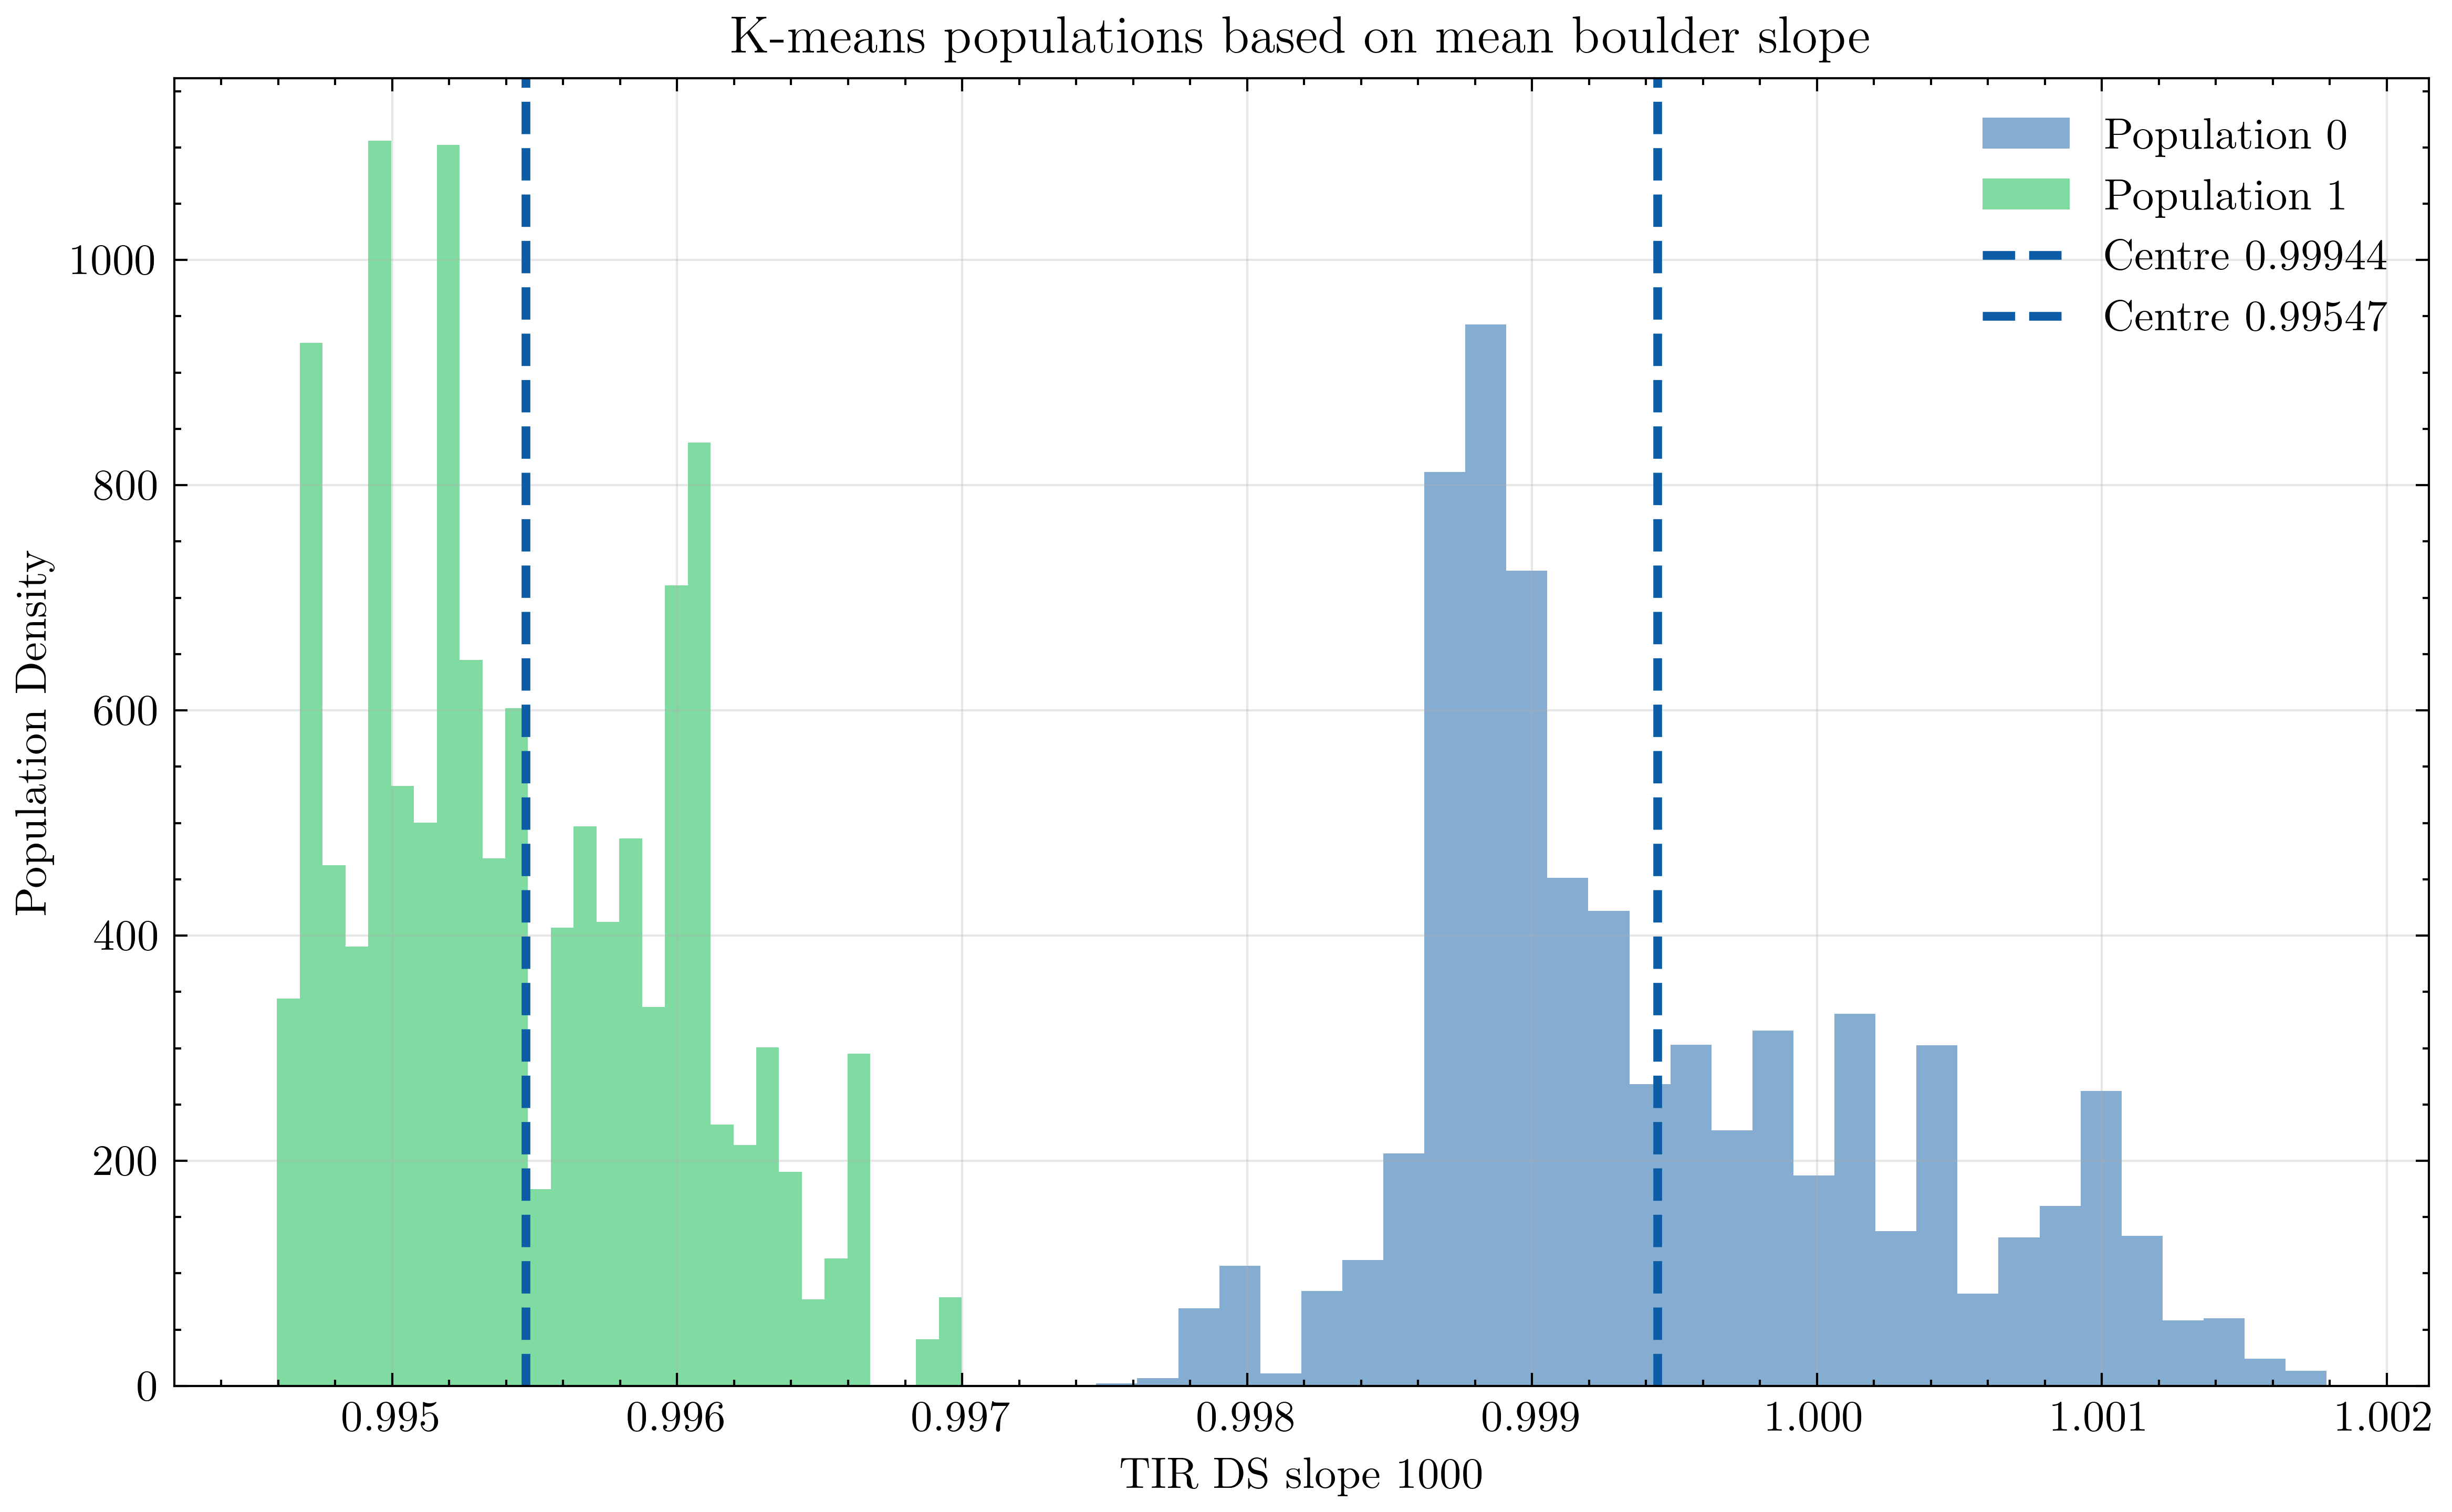

In [29]:
import matplotlib.pyplot as plt

df_plot = X.to_pandas()

plt.figure(figsize=(8, 5))

for pop in sorted(df_plot["population"].unique()):
    gamma = df_plot.loc[
        df_plot["population"] == pop,
        z_item
    ]

    plt.hist(
        gamma,
        bins=30,
        alpha=0.5,
        density=True,
        label=f"Population {pop}"
    )

# Plot cluster centres
for centre in centres[:, 0]:
    plt.axvline(
        centre,
        linestyle="--",
        linewidth=2,
        label=f"Centre {centre:.5f}"
    )

plt.xlabel(z_item)
plt.ylabel("Population Density")
plt.title("K-means populations based on mean boulder slope")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()